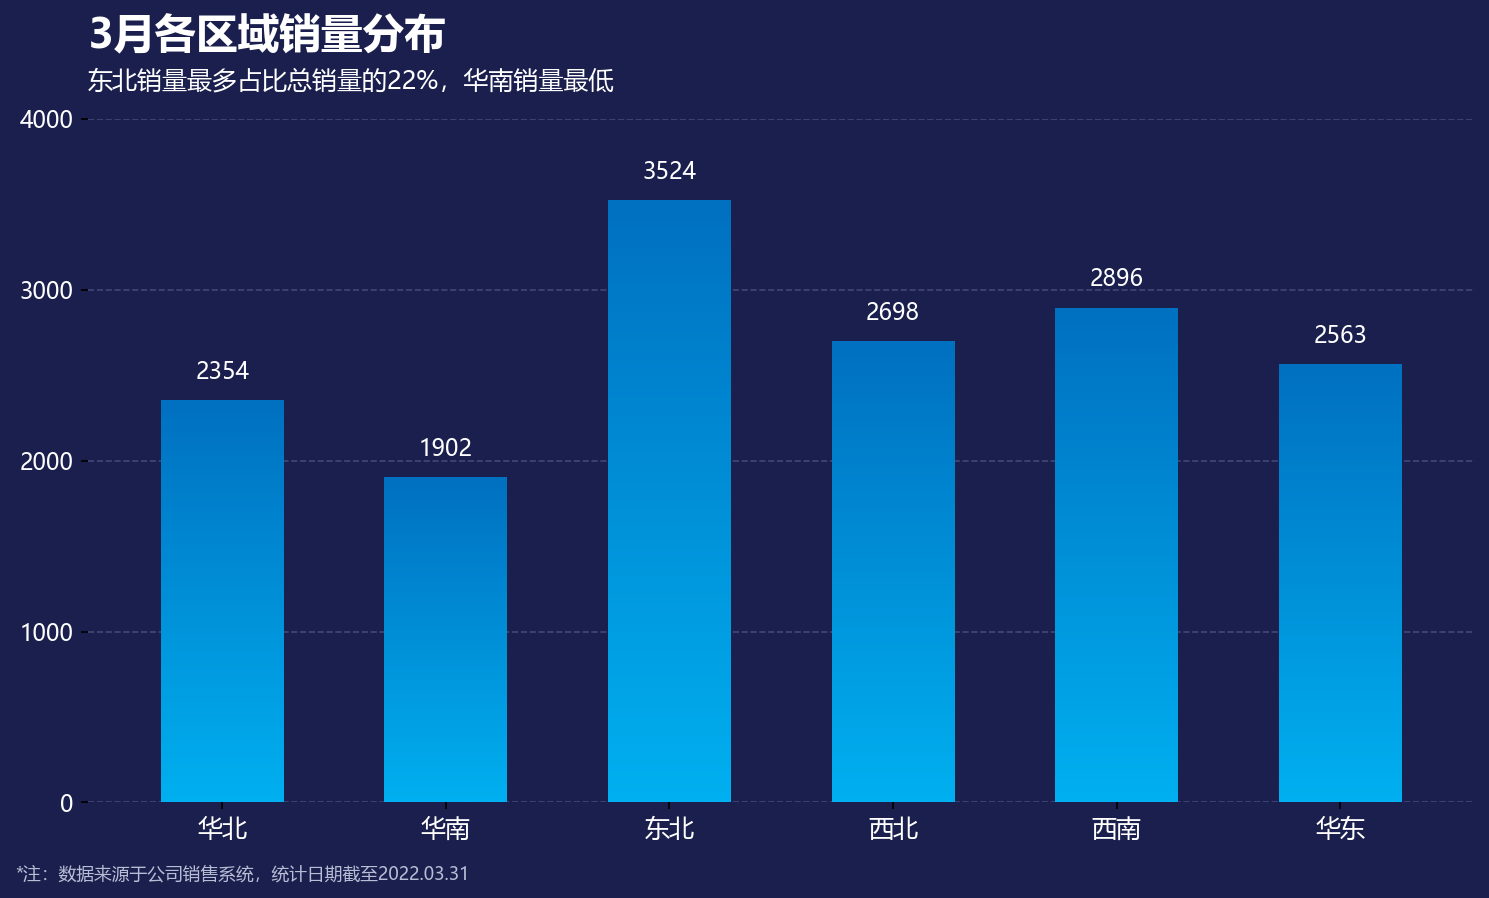

In [54]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

regions = ["华北", "华南", "东北", "西北", "西南", "华东"]
sales = [2354, 1902, 3524, 2698, 2896, 2563]
total = sum(sales)

BG = "#1a1f4d"
GRAD = LinearSegmentedColormap.from_list("bar_grad", ["#00B0F0", "#0070C0"])
TEXT = "#ffffff"
GRID = "#5a6394"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

def gradient_bar(ax, x, height, width=0.55, cmap=GRAD):
    img = np.linspace(0, 1, 256).reshape(-1, 1)
    im = ax.imshow(img, extent=[x - width/2, x + width/2, 0, height], origin="lower", aspect="auto", cmap=cmap, zorder=3)
    patch = mpl.patches.Rectangle((x - width/2, 0), width, height, transform=ax.transData)
    ax.add_patch(patch)
    im.set_clip_path(patch)

x = np.arange(len(regions))
for xi, h in zip(x, sales):
    gradient_bar(ax, xi, h)

for xi, h in zip(x, sales):
    ax.text(xi, h + 90, f"{h}", ha="center", va="bottom", color=TEXT, fontsize=11)

ax.set_xlim(-0.6, len(regions) - 0.4)
ax.set_ylim(0, 4000)
ax.set_xticks(x)
ax.set_xticklabels(regions, color=TEXT, fontsize=12)
ax.set_yticks(range(0, 4001, 1000))
ax.set_yticklabels([f"{v}" for v in range(0, 4001, 1000)], color=TEXT, fontsize=11)

ax.grid(axis="y", color=GRID, linestyle="--", linewidth=0.8, alpha=0.6, zorder=0)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("3月各区域销量分布", loc="left", color=TEXT, fontsize=20, fontweight="bold", pad=34)
ax.text(0, 1.045, "东北销量最多占比总销量的22%，华南销量最低", transform=ax.transAxes, color=TEXT, fontsize=12)
fig.text(0.012, 0.015, "*注：数据来源于公司销售系统，统计日期截至2022.03.31", color="#b8bdd6", fontsize=8.5, ha="left")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("1 渐变柱形图.png", facecolor=BG, bbox_inches="tight")

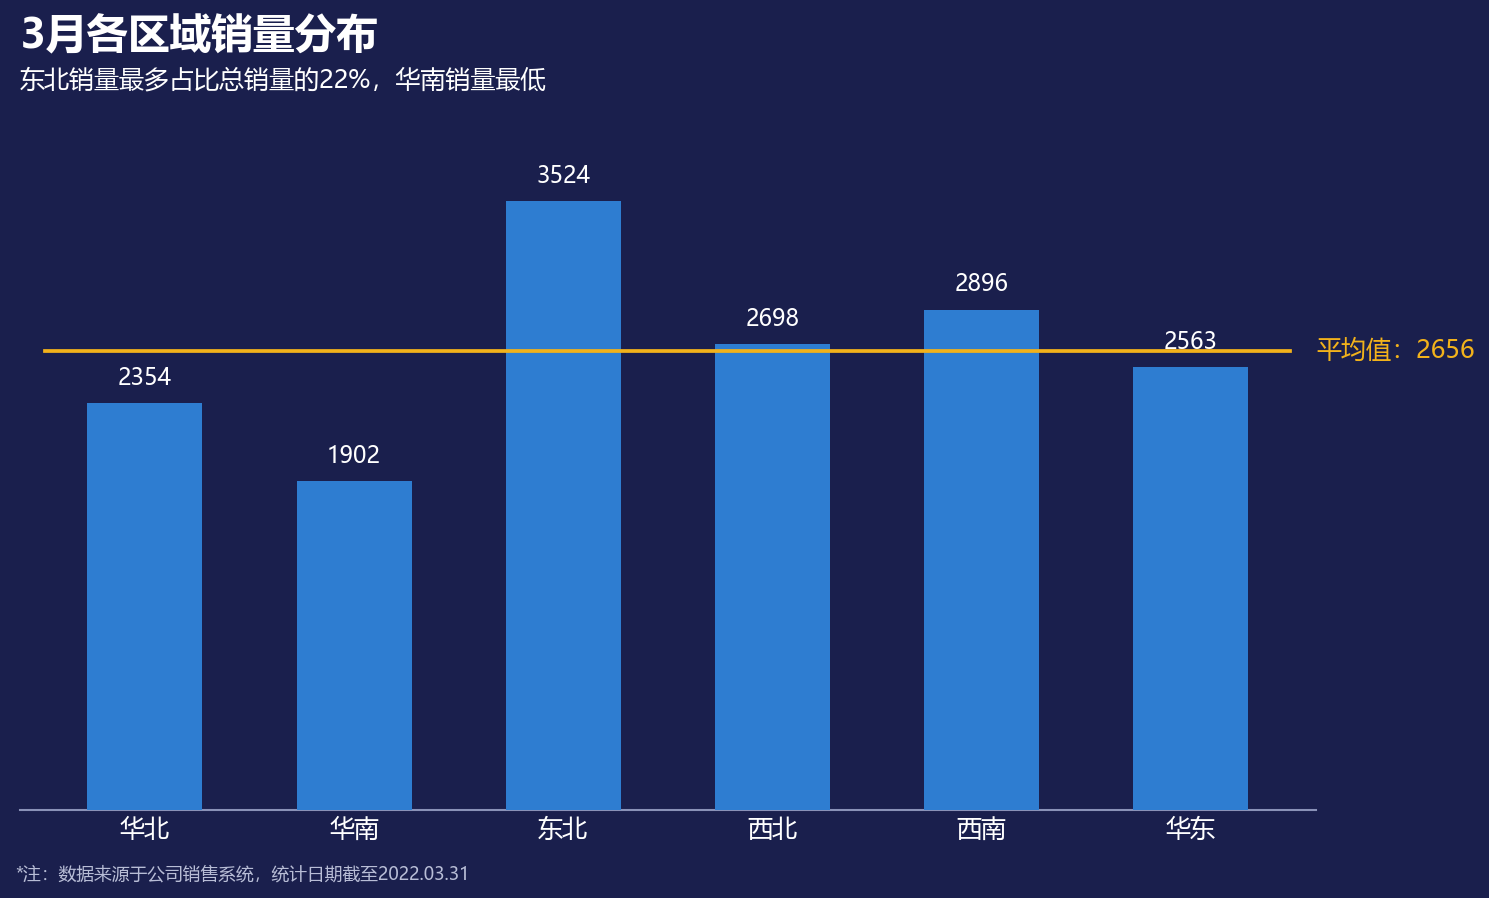

In [1]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

regions = ["华北", "华南", "东北", "西北", "西南", "华东"]
sales   = [2354, 1902, 3524, 2698, 2896, 2563]
mean_v  = sum(sales) / len(sales)

BG      = "#1a1f4d"
BAR     = "#2e7dd1"
LINE    = "#f2b21b"
TEXT    = "#ffffff"
FOOT    = "#b8bdd6"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

x = range(len(regions))
bars = ax.bar(x, sales, width=0.55, color=BAR, zorder=3)

for xi, h in zip(x, sales):
    ax.text(xi, h + 70, f"{h}", ha="center", va="bottom", color=TEXT, fontsize=11)

ax.axhline(y=2656, color=LINE, linewidth=1.8, xmin=0.02, xmax=0.98, zorder=4)
ax.text(1.0, 2656, f"平均值：2656", transform=ax.get_yaxis_transform(), ha="left", va="center", color=LINE, fontsize=12)

ax.set_xlim(-0.6, len(regions) - 0.4)
ax.set_ylim(0, 4000)
ax.set_xticks(list(x))
ax.set_xticklabels(regions, color=TEXT, fontsize=12)
ax.set_yticks([])
ax.tick_params(length=0)

ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color("#8a92b8")
ax.spines["bottom"].set_linewidth(1)
for name, spine in ax.spines.items():
    if name != "bottom":
        spine.set_visible(False)

ax.set_title("3月各区域销量分布", loc="left", color=TEXT, fontsize=20, fontweight="bold", pad=34)
ax.text(0, 1.045, "东北销量最多占比总销量的22%，华南销量最低", transform=ax.transAxes, color=TEXT, fontsize=12)
fig.text(0.012, 0.015, "*注：数据来源于公司销售系统，统计日期截至2022.03.31", color=FOOT, fontsize=8.5, ha="left")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("2 带均值柱形图.png", facecolor=BG, bbox_inches="tight")

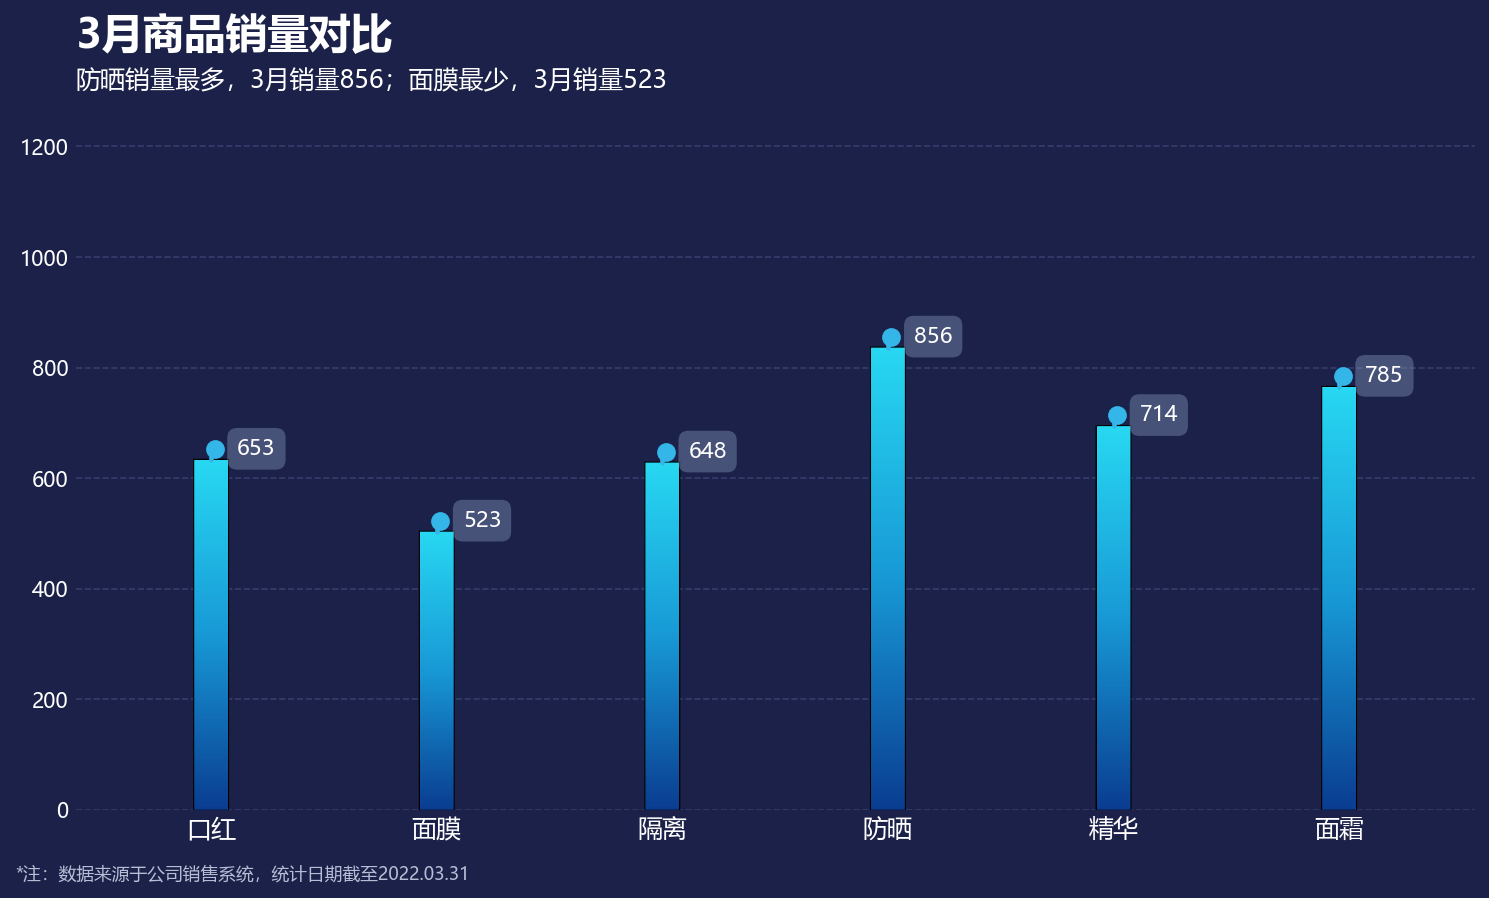

In [52]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, Circle
import numpy as np

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

items = ["口红", "面膜", "隔离", "防晒", "精华", "面霜"]
sales = [653, 523, 648, 856, 714, 785]

BG = "#1b2148"
GRAD = LinearSegmentedColormap.from_list("cap_grad", ["#0a3d91", "#1899d6", "#28d8f2"])
DOT  = "#35b6e8"
TEXT = "#ffffff"
GRID = "#4a5488"
FOOT = "#b8bdd6"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

BAR_W = 0.15 
GAP  = 20
STEM_W = 2.2

def rounded_bar(ax, x, height, width=BAR_W):
    r = 0.055
    box = FancyBboxPatch((x - width/2, 0), width, height, boxstyle=f"round,pad=0,rounding_size={r}", mutation_aspect=0.012, transform=ax.transData, zorder=3)
    ax.add_patch(box)
    img = np.linspace(0, 1, 256).reshape(-1, 1)
    im = ax.imshow(img, extent=[x - width/2, x + width/2, 0, height], origin="lower", aspect="auto", cmap=GRAD, zorder=3)
    im.set_clip_path(box)
    ax.plot([x, x], [height, height + GAP], color=DOT, linewidth=STEM_W, solid_capstyle="round", zorder=4)

x = np.arange(len(items))
for xi, h in zip(x, sales):
    rounded_bar(ax, xi, h - GAP)
    ax.plot(xi + 0.015, h, "o", ms=8, color=DOT, zorder=5)
    ax.text(xi + 0.115, h, f"{h}", ha="left", va="center", color=TEXT, fontsize=10.5, zorder=5, bbox=dict(boxstyle="round,pad=0.45", fc="#8fa3c8", alpha=0.38, ec="none"))

ax.set_xlim(-0.6, len(items) - 0.4)
ax.set_ylim(0, 1250)
ax.set_xticks(list(x))
ax.set_xticklabels(items, color=TEXT, fontsize=12)
ax.set_yticks(range(0, 1201, 200))
ax.set_yticklabels([str(v) for v in range(0, 1201, 200)], color=TEXT, fontsize=10)
ax.tick_params(length=0)

ax.grid(axis="y", color=GRID, linestyle="--", linewidth=0.8, alpha=0.55, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("3月商品销量对比", loc="left", color=TEXT, fontsize=20, fontweight="bold", pad=34)
ax.text(0, 1.045, "防晒销量最多，3月销量856；面膜最少，3月销量523", transform=ax.transAxes, color=TEXT, fontsize=12)
fig.text(0.012, 0.015, "*注：数据来源于公司销售系统，统计日期截至2022.03.31", color=FOOT, fontsize=8.5, ha="left")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("3 渐变圆角柱形图.png", facecolor=BG, bbox_inches="tight")

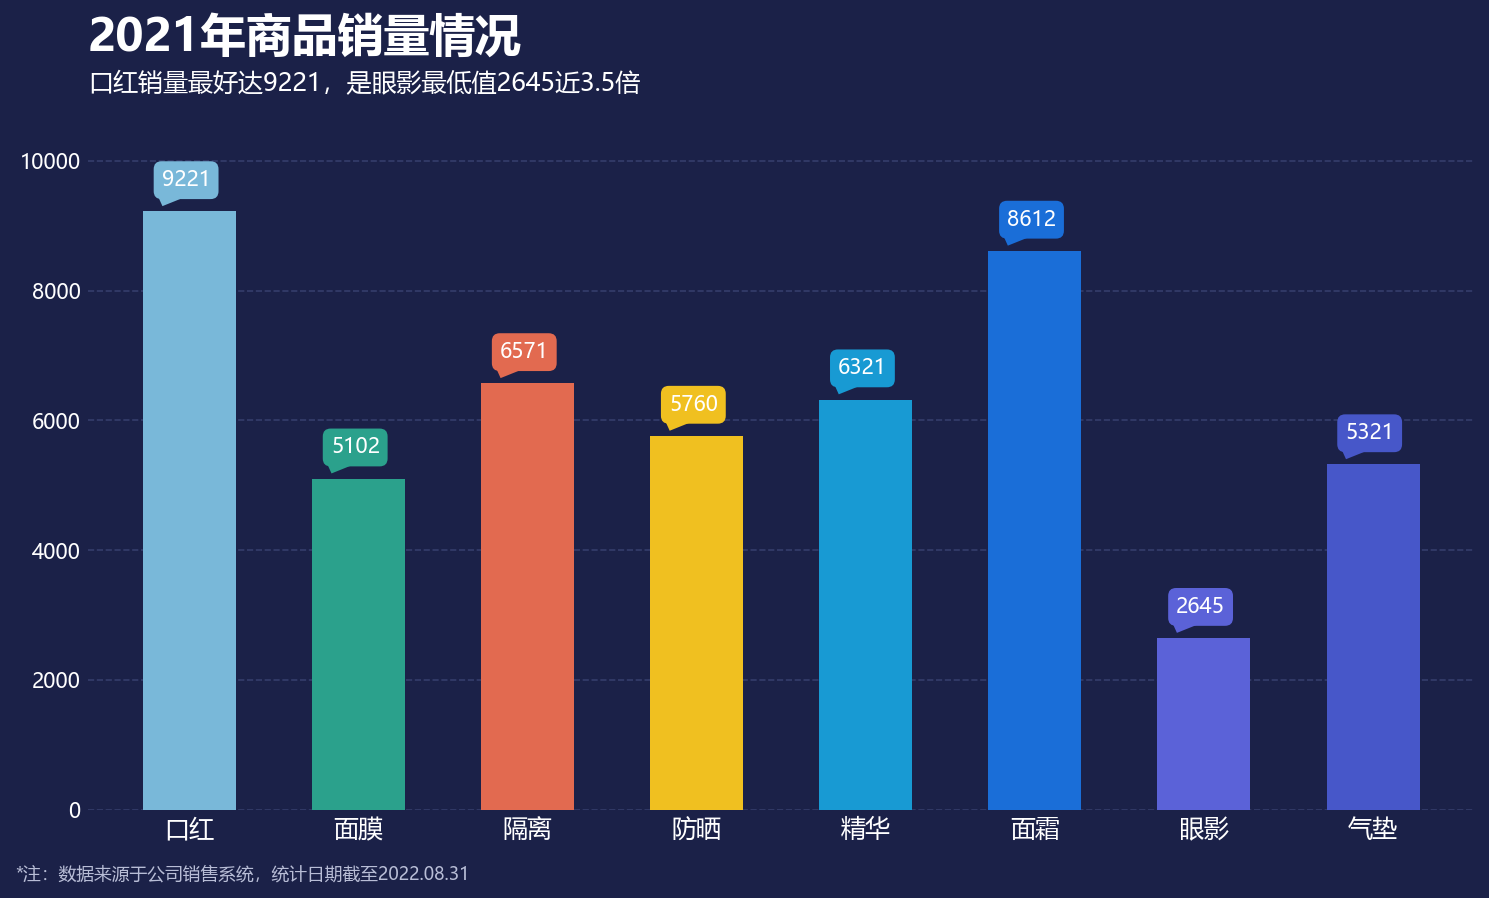

In [51]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

items = ["口红", "面膜", "隔离", "防晒", "精华", "面霜", "眼影", "气垫"]
sales = [9221, 5102, 6571, 5760, 6321, 8612, 2645, 5321]
colors = ["#79b8d9", "#2ba18c", "#e26a50", "#f0c020", "#189ad3", "#1a6ed8", "#5b62d8", "#4757c9"]

BG   = "#1b2148"
TEXT = "#ffffff"
GRID = "#4a5488"
FOOT = "#b8bdd6"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

x = range(len(items))

bars = ax.bar(x, sales, width=0.55, color=colors, zorder=3)

TAG_DY = 480
TAIL_DY = 310
for xi, h, c in zip(x, sales, colors):
    ax.text(xi - 0.02, h + TAG_DY, f"{h}", ha="center", va="center", color=TEXT, fontsize=10, zorder=5,  bbox=dict(boxstyle="round,pad=0.38", fc=c, ec="none"))
    tail = Polygon([[xi - 0.20, h + TAIL_DY], [xi + 0.06, h + TAIL_DY], [xi - 0.16, h + TAIL_DY - 230]], closed=True, fc=c, ec="none", zorder=4)
    ax.add_patch(tail)

ax.set_xlim(-0.6, len(items) - 0.4)
ax.set_ylim(0, 10600)
ax.set_xticks(list(x))
ax.set_xticklabels(items, color=TEXT, fontsize=12)
ax.set_yticks(range(0, 10001, 2000))
ax.set_yticklabels([str(v) for v in range(0, 10001, 2000)], color=TEXT, fontsize=10)
ax.tick_params(length=0)

ax.grid(axis="y", color=GRID, linestyle="--", linewidth=0.8, alpha=0.55, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("2021年商品销量情况", loc="left", color=TEXT, fontsize=22, fontweight="bold", pad=34)
ax.text(0, 1.045, "口红销量最好达9221，是眼影最低值2645近3.5倍", transform=ax.transAxes, color=TEXT, fontsize=12)
fig.text(0.012, 0.015, "*注：数据来源于公司销售系统，统计日期截至2022.08.31", color=FOOT, fontsize=8.5, ha="left")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("4 标注柱形图.png", facecolor=BG, bbox_inches="tight")

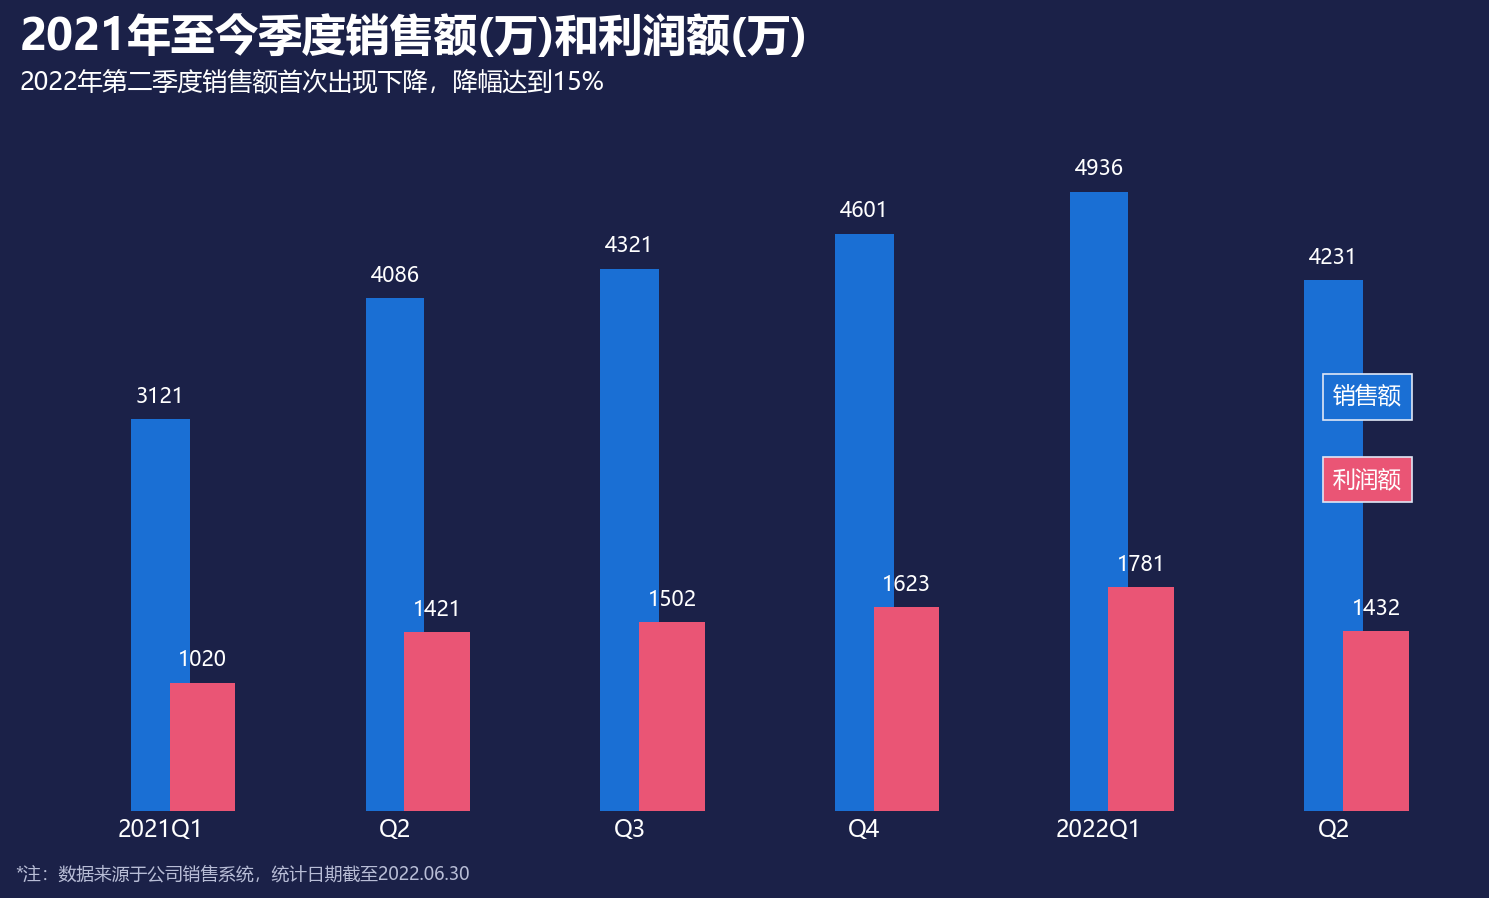

In [50]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

quarters = ["2021Q1", "Q2", "Q3", "Q4", "2022Q1", "Q2"]
sales  = [3121, 4086, 4321, 4601, 4936, 4231]
profit = [1020, 1421, 1502, 1623, 1781, 1432]

BG    = "#1b2148"
BLUE  = "#1a6fd4"
PINK  = "#ea5575"
TEXT  = "#ffffff"
FOOT  = "#b8bdd6"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

x = np.arange(len(quarters))
W_SALES  = 0.25
W_PROFIT = 0.28 
OFFSET   = 0.18

b1 = ax.bar(x, sales, width=W_SALES, color=BLUE, zorder=3, label="销售额")
b2 = ax.bar(x + OFFSET, profit, width=W_PROFIT, color=PINK, zorder=4, label="利润额")

for r in b1:
    ax.text(r.get_x() + r.get_width()/2, r.get_height() + 90,
            f"{int(r.get_height())}", ha="center", va="bottom",
            color=TEXT, fontsize=10, zorder=5)
for r in b2:
    ax.text(r.get_x() + r.get_width()/2, r.get_height() + 90,
            f"{int(r.get_height())}", ha="center", va="bottom",
            color=TEXT, fontsize=10, zorder=5)

ax.text(0.95, 0.60, "销售额", transform=ax.transAxes, ha="right", va="center",
        color=TEXT, fontsize=11,
        bbox=dict(boxstyle="square,pad=0.45", fc=BLUE, ec="#dfe6f5", lw=0.8))
ax.text(0.95, 0.48, "利润额", transform=ax.transAxes, ha="right", va="center",
        color=TEXT, fontsize=11,
        bbox=dict(boxstyle="square,pad=0.45", fc=PINK, ec="#dfe6f5", lw=0.8))

ax.set_xlim(-0.6, len(quarters) - 0.4)
ax.set_ylim(0, 5500)
ax.set_xticks(list(x))
ax.set_xticklabels(quarters, color=TEXT, fontsize=11)
ax.set_yticks([])
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("2021年至今季度销售额(万)和利润额(万)", loc="left", color=TEXT,
             fontsize=21, fontweight="bold", pad=34)
ax.text(0, 1.045, "2022年第二季度销售额首次出现下降，降幅达到15%",
        transform=ax.transAxes, color=TEXT, fontsize=12)
fig.text(0.012, 0.015, "*注：数据来源于公司销售系统，统计日期截至2022.06.30",
         color=FOOT, fontsize=8.5, ha="left")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("5 层叠柱形图.png", facecolor=BG, bbox_inches="tight")

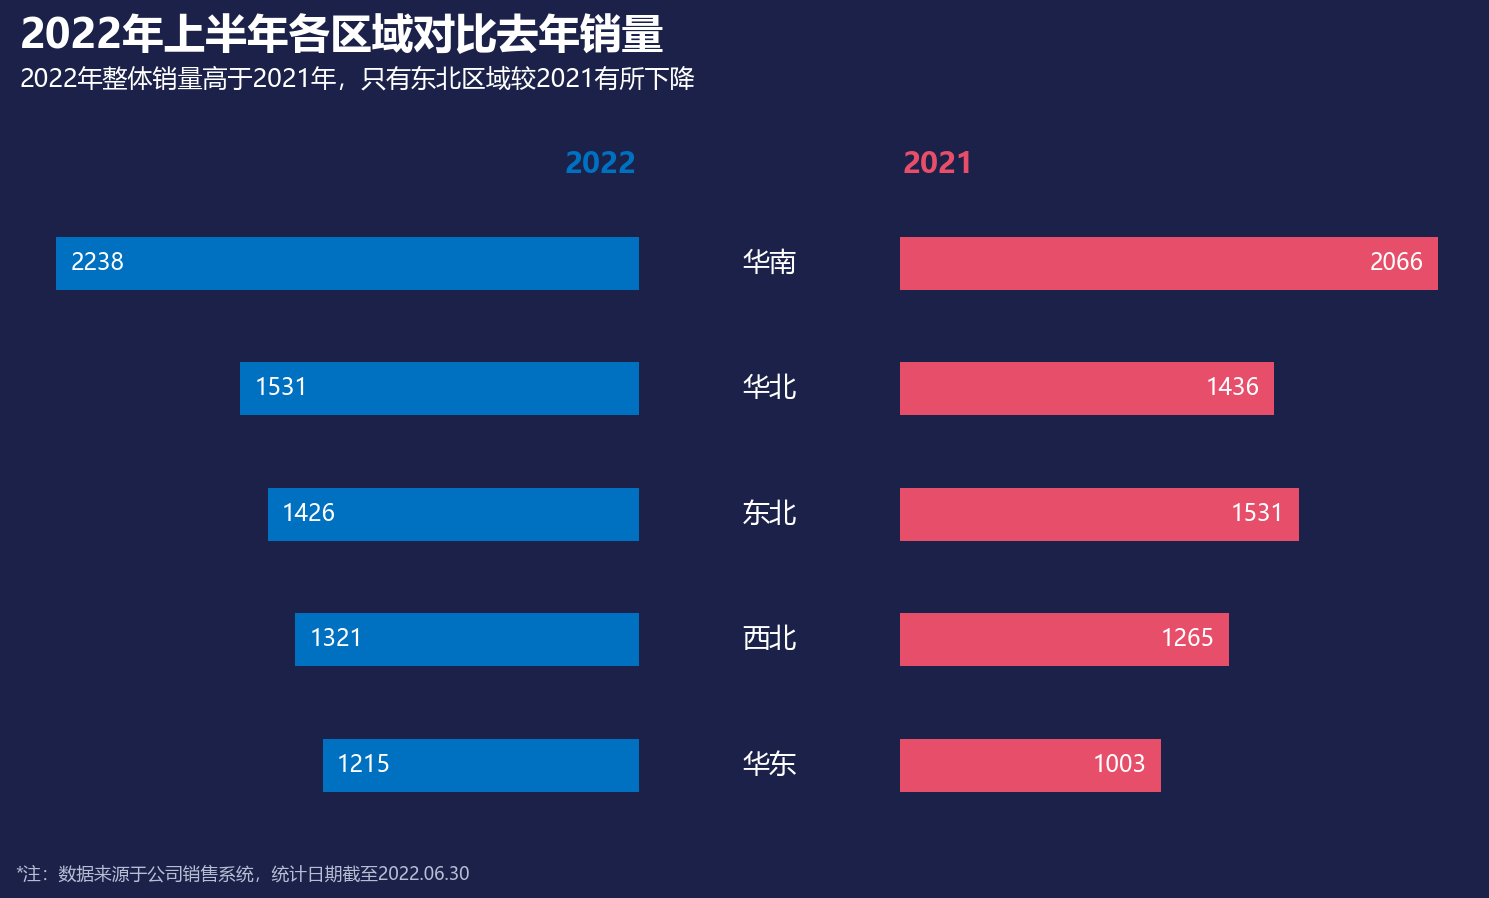

In [49]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

regions = ["华南", "华北", "东北", "西北", "华东"]
v22 = [2238, 1531, 1426, 1321, 1215]
v21 = [2066, 1436, 1531, 1265, 1003]

BG    = "#1b2148"
BLUE  = "#0070C0"
PINK  = "#E74E69"
TEXT  = "#ffffff"
FOOT  = "#b8bdd6"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

GAP      = 500 
BAR_H    = 0.42
ys       = range(len(regions) - 1, -1, -1)

for i, (y, a, b) in enumerate(zip(ys, v22, v21)):
    ax.barh(y, a, left=-GAP - a, height=BAR_H, color=BLUE, zorder=3)
    ax.barh(y, b, left=GAP,      height=BAR_H, color=PINK, zorder=3)
    ax.text(-GAP - a + 55, y, f"{a}", ha="left",  va="center",
            color=TEXT, fontsize=11, zorder=4)
    ax.text(GAP + b - 55, y, f"{b}", ha="right", va="center",
            color=TEXT, fontsize=11, zorder=4)
    ax.text(0, y, regions[i], ha="center", va="center",
            color=TEXT, fontsize=13, zorder=4)

ax.text(-650, len(regions) - 1 + 0.78, "2022", ha="center", va="center",
        color=BLUE, fontsize=14, fontweight="bold")
ax.text(650, len(regions) - 1 + 0.78, "2021", ha="center", va="center",
        color=PINK, fontsize=14, fontweight="bold")

ax.set_xlim(-GAP - max(v22) - 140, GAP + max(v21) + 140)
ax.set_ylim(-0.62, len(regions) - 1 + 1.15)
ax.axis("off")

ax.set_title("2022年上半年各区域对比去年销量", loc="left", color=TEXT,
             fontsize=20, fontweight="bold", pad=34)
ax.text(0, 1.045, "2022年整体销量高于2021年，只有东北区域较2021有所下降",
        transform=ax.transAxes, color=TEXT, fontsize=12)
fig.text(0.012, 0.015, "*注：数据来源于公司销售系统，统计日期截至2022.06.30",
         color=FOOT, fontsize=8.5, ha="left")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("6 蝴蝶图.png", facecolor=BG, bbox_inches="tight")

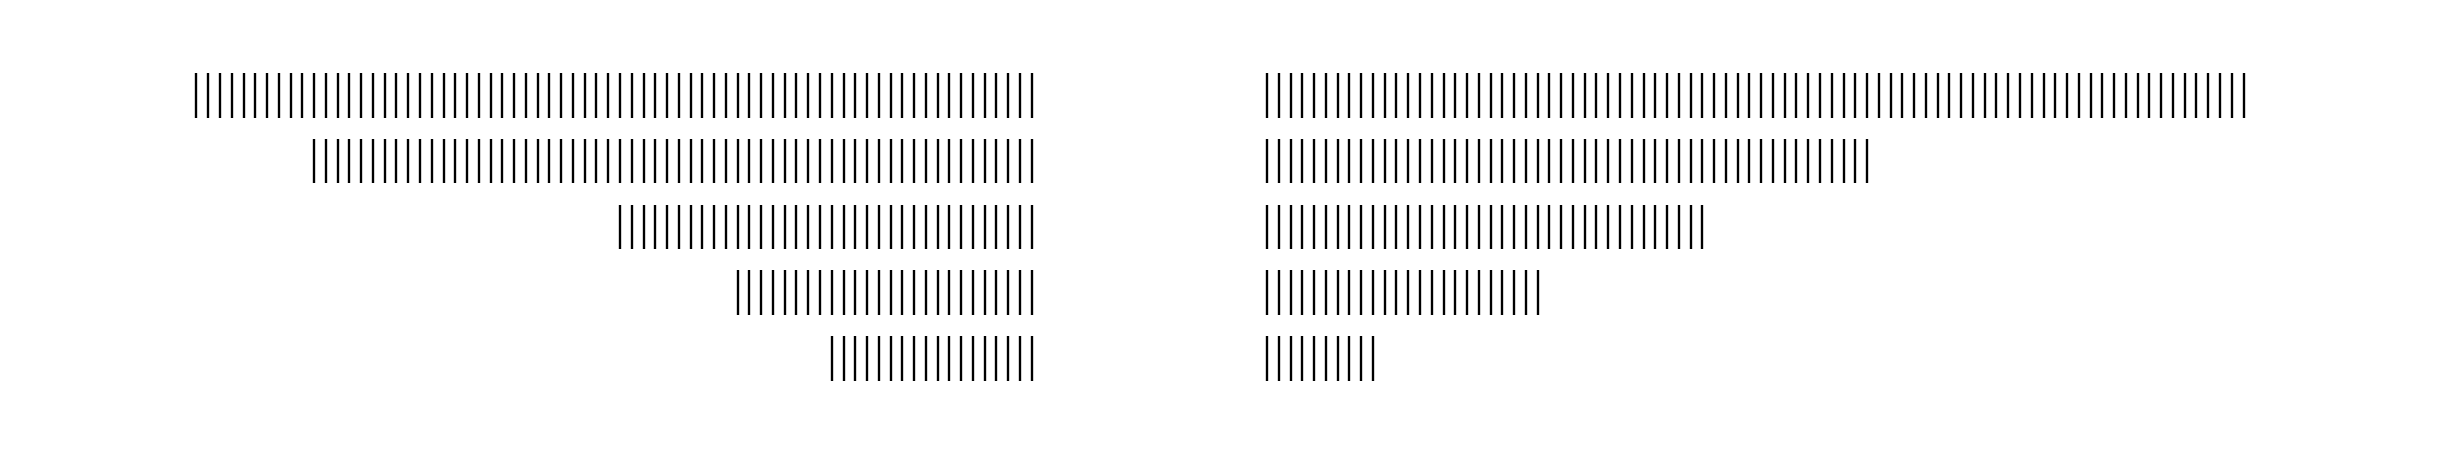

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.sans-serif"] = ["DengXian", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

BG, BAR = "#FFFFFF", "#000000"

v2022 = [0.36, 0.31, 0.18, 0.13, 0.09]
v2021 = [0.42, 0.26, 0.19, 0.12, 0.05]
REPT_N = 200 

Y0, ROW_H = 16, 28 
L_IN, R_IN = 570, 670                    
ADV, BAR_H = 5, 19                         
BAR_DY = 16                                 
XL0, XL1, YL1 = 140, 1160, 176             

fig = plt.figure(figsize=(12, 12 * YL1 / (XL1 - XL0)), dpi=200)
fig.patch.set_facecolor(BG)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(XL0, XL1)
ax.set_ylim(YL1, 0)                    
ax.axis("off")

for i in range(5):
    cy = Y0 + ROW_H * i + BAR_DY

    n = round(v2022[i] * REPT_N)           
    xs = L_IN - np.arange(n) * ADV          
    ax.vlines(xs, cy - BAR_H / 2, cy + BAR_H / 2, color=BAR, lw=0.85)

    n = round(v2021[i] * REPT_N)
    xs = R_IN + np.arange(n) * ADV    
    ax.vlines(xs, cy - BAR_H / 2, cy + BAR_H / 2, color=BAR, lw=0.85)

plt.savefig("7 蝴蝶图t.png", facecolor=BG, dpi=200)

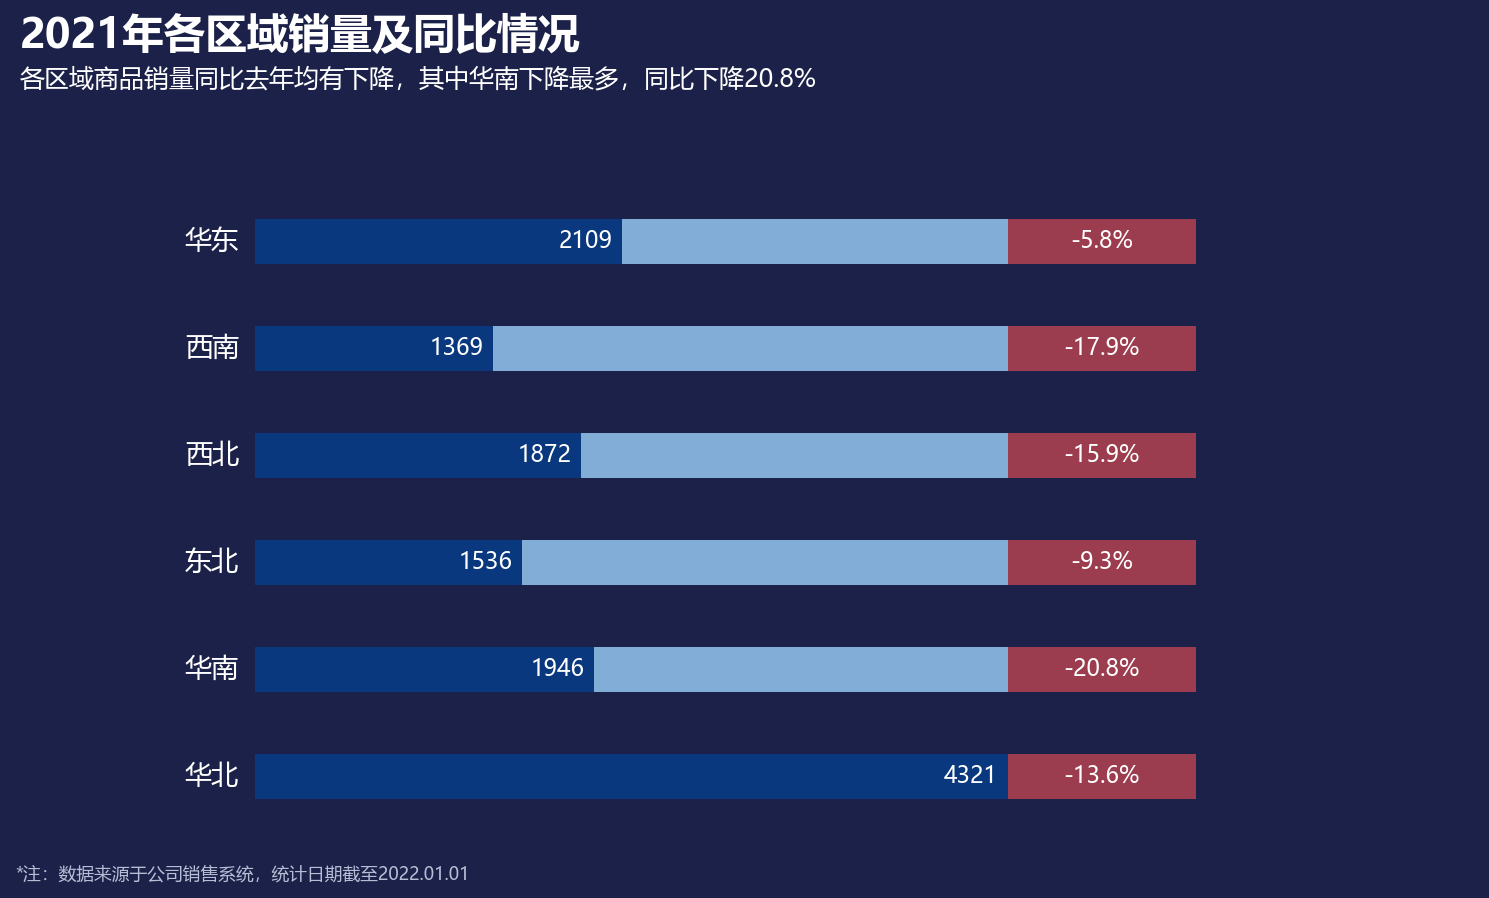

In [48]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

regions = ["华北", "华南", "东北", "西北", "西南", "华东"]
sales   = [4321, 1946, 1536, 1872, 1369, 2109]
pct     = [-13.6, -20.8, -9.3, -15.9, -17.9, -5.8]

MAX_S   = max(sales)
RED_W   = MAX_S / 4 
TOTAL   = MAX_S + RED_W 

BG    = "#1b2148"
DARK  = "#09387E"
LIGHT = "#82ADD7" 
RED   = "#9B3D4F"
TEXT  = "#ffffff"
FOOT  = "#b8bdd6"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

BAR_H = 0.42
for i, (r, s, p) in enumerate(zip(regions, sales, pct)):
    ax.barh(i, s,            height=BAR_H, color=DARK,  zorder=3)
    ax.barh(i, TOTAL - RED_W - s, height=BAR_H, left=s,
            color=LIGHT, zorder=3)
    ax.barh(i, RED_W, height=BAR_H, left=TOTAL - RED_W, color=RED, zorder=3)
    ax.text(s - 55, i, f"{s}", ha="right", va="center",
            color=TEXT, fontsize=11, zorder=4)
    ax.text(TOTAL - RED_W / 2, i, f"{p:.1f}%", ha="center", va="center",
            color=TEXT, fontsize=11, zorder=4)
    ax.text(-90, i, r, ha="right", va="center", color=TEXT, fontsize=13)

ax.set_xlim(-1350, TOTAL + 1600)
ax.set_ylim(-0.62, len(regions) - 1 + 1.15)
ax.axis("off")

ax.set_title("2021年各区域销量及同比情况", loc="left", color=TEXT,
             fontsize=20, fontweight="bold", pad=34)
ax.text(0, 1.045, "各区域商品销量同比去年均有下降，其中华南下降最多，同比下降20.8%",
        transform=ax.transAxes, color=TEXT, fontsize=12)
fig.text(0.012, 0.015, "*注：数据来源于公司销售系统，统计日期截至2022.01.01",
         color=FOOT, fontsize=8.5, ha="left")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("8 数值百分比.png", facecolor=BG, bbox_inches="tight")

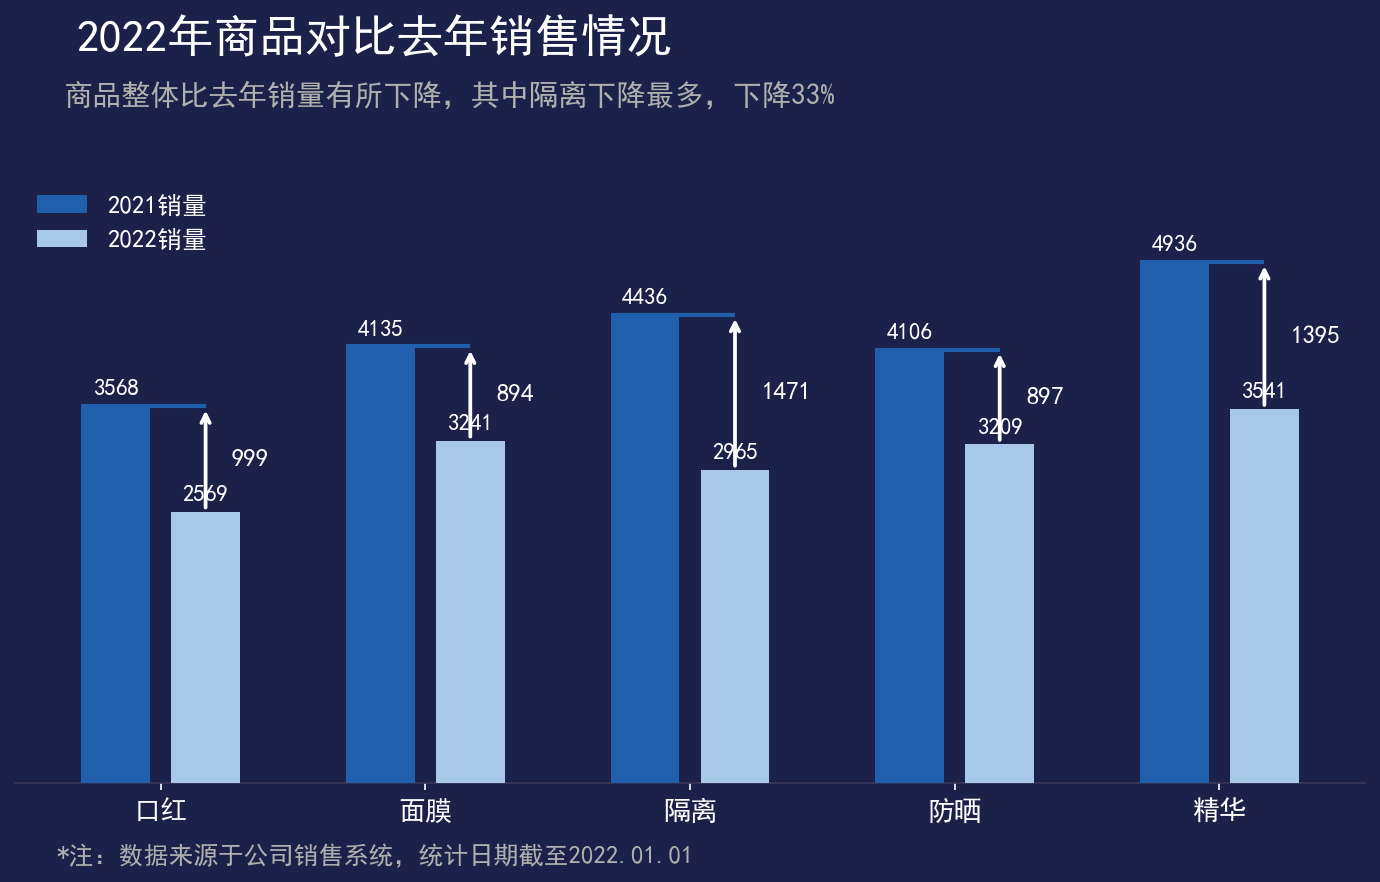

In [56]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False


BG    = "#1b2148"
DARK  = "#09387E"
LIGHT = "#82ADD7" 
TEXT = '#FFFFFF'
SUB = '#B0B0B0'
GRID = '#3A3A5A'


goods = ['口红', '面膜', '隔离', '防晒', '精华']
v2021 = [3568, 4135, 4436, 4106, 4936]
v2022 = [2569, 3241, 2965, 3209, 3541]
diffs = [a - b for a, b in zip(v2021, v2022)]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
fig.subplots_adjust(left=0.06, right=0.96, top=0.78, bottom=0.10)

for sp in ['top', 'right', 'left']:
    ax.spines[sp].set_visible(False)
ax.spines['bottom'].set_color(GRID)

ax.set_yticks([])
ax.tick_params(axis='x', colors=TEXT, labelsize=13)

ax.yaxis.grid(False)
ax.set_axisbelow(True)

x = np.arange(len(goods))
w = 0.26
gap = 0.08
offset = w/2 + gap/2

ax.bar(x - offset, v2021, w, color=DARK_BLUE, zorder=3)
ax.bar(x + offset, v2022, w, color=LIGHT_BLUE, zorder=3)

for i, v in enumerate(v2021):
    x_left = i - offset - w/2
    x_right = i + offset
    ax.plot([x_left, x_right], [v, v], color=DARK_BLUE,
            linewidth=2, solid_capstyle='butt', zorder=8)

for i, v in enumerate(v2021):
    ax.text(i - offset, v + 80, str(v), ha='center', va='bottom',
            fontsize=11, color=TEXT)
for i, v in enumerate(v2022):
    ax.text(i + offset, v + 80, str(v), ha='center', va='bottom',
            fontsize=11, color=TEXT)

for i, (a, b, d) in enumerate(zip(v2021, v2022, diffs)):
    x_pos = i + offset
    ax.annotate('', xy=(x_pos, a), xytext=(x_pos, b),
                arrowprops=dict(arrowstyle='->', color='white',
                                lw=1.8, shrinkA=2, shrinkB=2), zorder=5)
    ax.text(x_pos + 0.10, (a + b) / 2, f'{d}', ha='left', va='center',
            fontsize=12, color=TEXT, fontweight='bold', zorder=7)

ax.set_xticks(x)
ax.set_xticklabels(goods, fontsize=13)
ax.set_ylim(0, 5800)
ax.set_xlim(-0.55, len(goods) - 0.45)

ax.legend(handles=[Patch(facecolor=DARK_BLUE, label='2021销量'),
                   Patch(facecolor=LIGHT_BLUE, label='2022销量')],
          frameon=False, labelcolor=TEXT,
          loc='upper left', fontsize=12)

fig.text(0.3, 0.93, '2022年商品对比去年销售情况',
         ha='center', va='center', fontsize=22,
         fontweight='bold', color=TEXT)
fig.text(0.35, 0.865, '商品整体比去年销量有所下降，其中隔离下降最多，下降33%',
         ha='center', va='center', fontsize=14, color=SUB)
fig.text(0.3, 0.02, '*注：数据来源于公司销售系统，统计日期截至2022.01.01',
         ha='center', va='center', fontsize=12, color=SUB)

plt.savefig("9 对比柱形图.png", facecolor=BG, dpi=200)

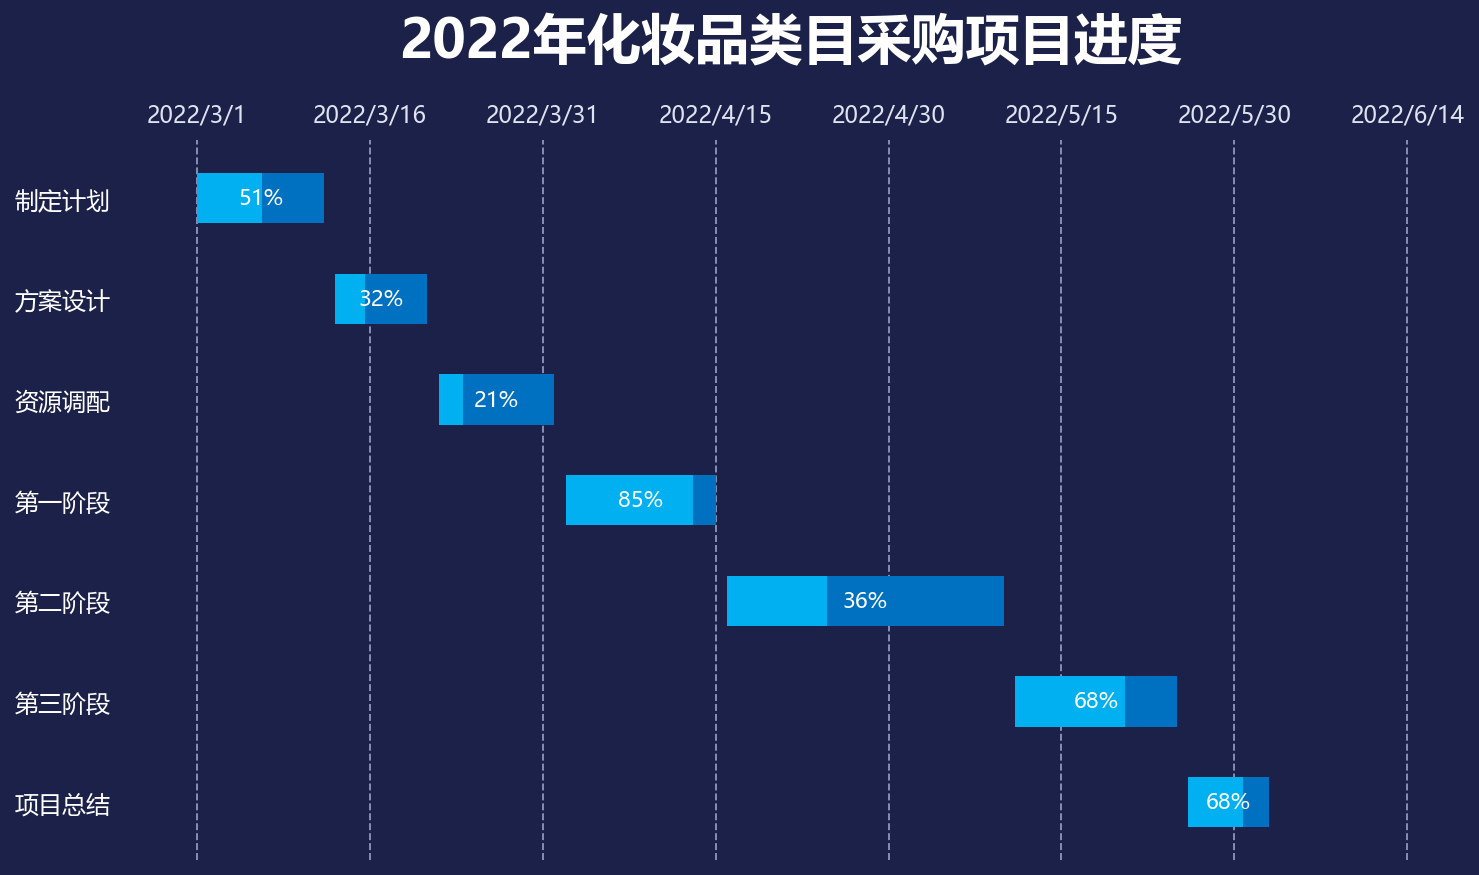

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date, timedelta

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

tasks   = ["制定计划", "方案设计", "资源调配", "第一阶段", "第二阶段", "第三阶段", "项目总结"]
starts  = [date(2022, 3, 1),  date(2022, 3, 13), date(2022, 3, 22),
           date(2022, 4, 2),  date(2022, 4, 16), date(2022, 5, 11), date(2022, 5, 26)]
days    = [11, 8, 10, 13, 24, 14, 7]
prog    = [5.61, 2.56, 2.1, 11.05, 8.64, 9.52, 4.76]
pct     = [51, 32, 21, 85, 36, 68, 68]

BG     = "#1b2148"
BRIGHT = "#00B0F0"
DARK   = "#0070C0" 
TEXT   = "#ffffff"
DATEFG = "#dfe3f0"
GRIDC  = "#8a93b8"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

y = np.arange(len(tasks))
for i in range(len(tasks)):
    x0 = mdates.date2num(starts[i]) 
    ax.barh(y[i], prog[i],        left=x0,      height=0.5, color=BRIGHT, zorder=3)
    ax.barh(y[i], days[i] - prog[i], left=x0 + prog[i], height=0.5,
            color=DARK, zorder=3)
    ax.text(x0 + days[i] / 2, y[i], f"{pct[i]}%", ha="center", va="center",
            color=TEXT, fontsize=10.5, zorder=4)

ticks  = [date(2022, 3, 1) + timedelta(days=15 * k) for k in range(8)]
labels = [f"{d.year}/{d.month}/{d.day}" for d in ticks]
ax.set_xticks([mdates.date2num(d) for d in ticks])
ax.set_xticklabels(labels, color=DATEFG, fontsize=11)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False,
               length=0, pad=6)
ax.set_yticks(y)
ax.set_yticklabels(tasks, color=TEXT, fontsize=11.5)
ax.tick_params(axis="y", length=0, pad=8)

ax.set_axisbelow(True) 
ax.grid(axis="x", ls="--", lw=0.9, color=GRIDC)
ax.set_xlim(mdates.date2num(date(2022, 2, 23)), mdates.date2num(date(2022, 6, 18)))
ax.invert_yaxis() 
for side in ("top", "right", "bottom", "left"):
    ax.spines[side].set_visible(False)

ax.set_title("2022年化妆品类目采购项目进度", loc="center", color=TEXT,
             fontsize=26, fontweight="bold", pad=22)

plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.savefig("10 甘特图.png", facecolor=BG, bbox_inches="tight")

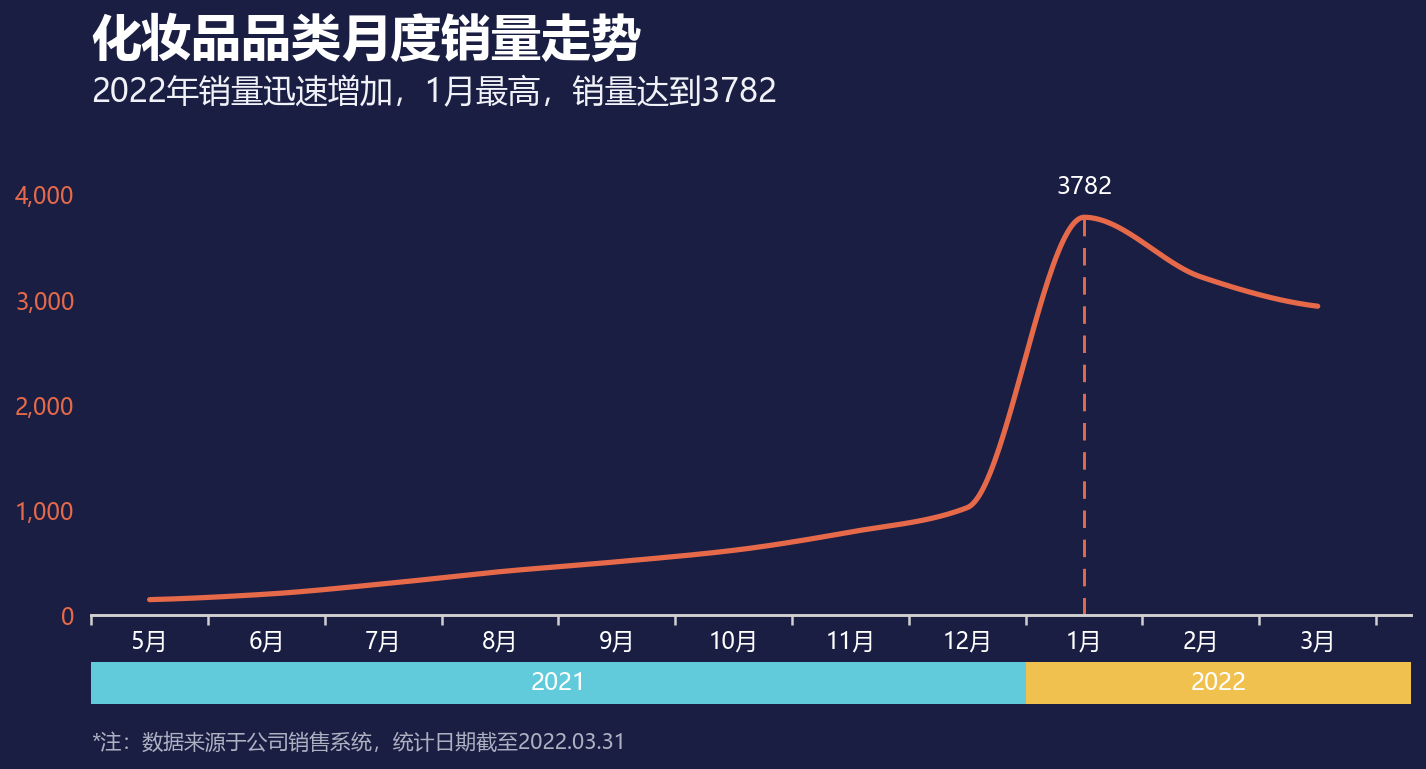

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
from matplotlib.patches import Rectangle
from scipy.interpolate import PchipInterpolator

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

months = ["5月", "6月", "7月", "8月", "9月", "10月", "11月", "12月", "1月", "2月", "3月"]
sales  = [146, 198, 296, 412, 506, 615, 789, 1021, 3782, 3215, 2936]
PEAK   = 8 

BG     = "#1A1E43"
LINE   = "#E66A4A"
CYAN   = "#62CBDB"
YELLOW = "#F1C14F" 
TEXT   = "#FFFFFF"
SOFT   = "#F0F2F8"
GRAY   = "#AEB1C2" 
AXIS   = "#D0D0D0"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
fig.subplots_adjust(left=0.09, right=0.97, top=0.78, bottom=0.26)

x  = np.arange(len(months))
xs = np.linspace(0, len(months) - 1, 500)
ys = PchipInterpolator(x, sales)(xs)
ax.plot(xs, ys, color=LINE, lw=2.5, solid_capstyle="round", zorder=3)

ax.vlines(PEAK, 0, sales[PEAK], color=LINE, ls=(0, (6, 4)), lw=1.4, zorder=2)
ax.text(PEAK, sales[PEAK] + 170, f"{sales[PEAK]}", ha="center", va="bottom",
        color=TEXT, fontsize=11.5, zorder=4)

ax.set_xlim(-0.5, 10.8)
ax.set_ylim(0, 4450)
ax.set_yticks([0, 1000, 2000, 3000, 4000])
ax.set_yticklabels(["0", "1,000", "2,000", "3,000", "4,000"], fontsize=11)
ax.tick_params(axis="y", labelcolor=LINE, length=0, pad=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color(AXIS)
ax.spines["bottom"].set_linewidth(1.4)

ax.set_xticks(np.arange(-0.5, 10.6, 1))
ax.tick_params(axis="x", color=AXIS, length=4.7, width=1.2,
               direction="out", bottom=True, labelbottom=False)

tr2 = blended_transform_factory(ax.transData, ax.transAxes)
for i, m in enumerate(months):
    ax.text(i, -0.03, m, transform=tr2, ha="center", va="top",
            color=TEXT, fontsize=11)

tr = blended_transform_factory(ax.transData, ax.transAxes)
ax.add_patch(Rectangle((-0.5, -0.19), 8.0, 0.09, transform=tr,
                       facecolor=CYAN, edgecolor="none", clip_on=False))
ax.add_patch(Rectangle((7.5, -0.19), 3.3, 0.09, transform=tr,
                       facecolor=YELLOW, edgecolor="none", clip_on=False))
ax.text(3.5, -0.145, "2021", transform=tr, ha="center", va="center",
        color=TEXT, fontsize=11.5)
ax.text(9.15, -0.145, "2022", transform=tr, ha="center", va="center",
        color=TEXT, fontsize=11.5)

ax.text(0.0, 1.17, "化妆品品类月度销量走势", transform=ax.transAxes,
        color=TEXT, fontsize=24, fontweight="bold", va="bottom")
ax.text(0.0, 1.08, "2022年销量迅速增加，1月最高，销量达到3782", transform=ax.transAxes,
        color=SOFT, fontsize=15.5, va="bottom")
ax.text(0.0, -0.25, "*注：数据来源于公司销售系统，统计日期截至2022.03.31",
        transform=ax.transAxes, color=GRAY, fontsize=10, va="top")

plt.savefig("11 平滑折线图.png", facecolor=BG)

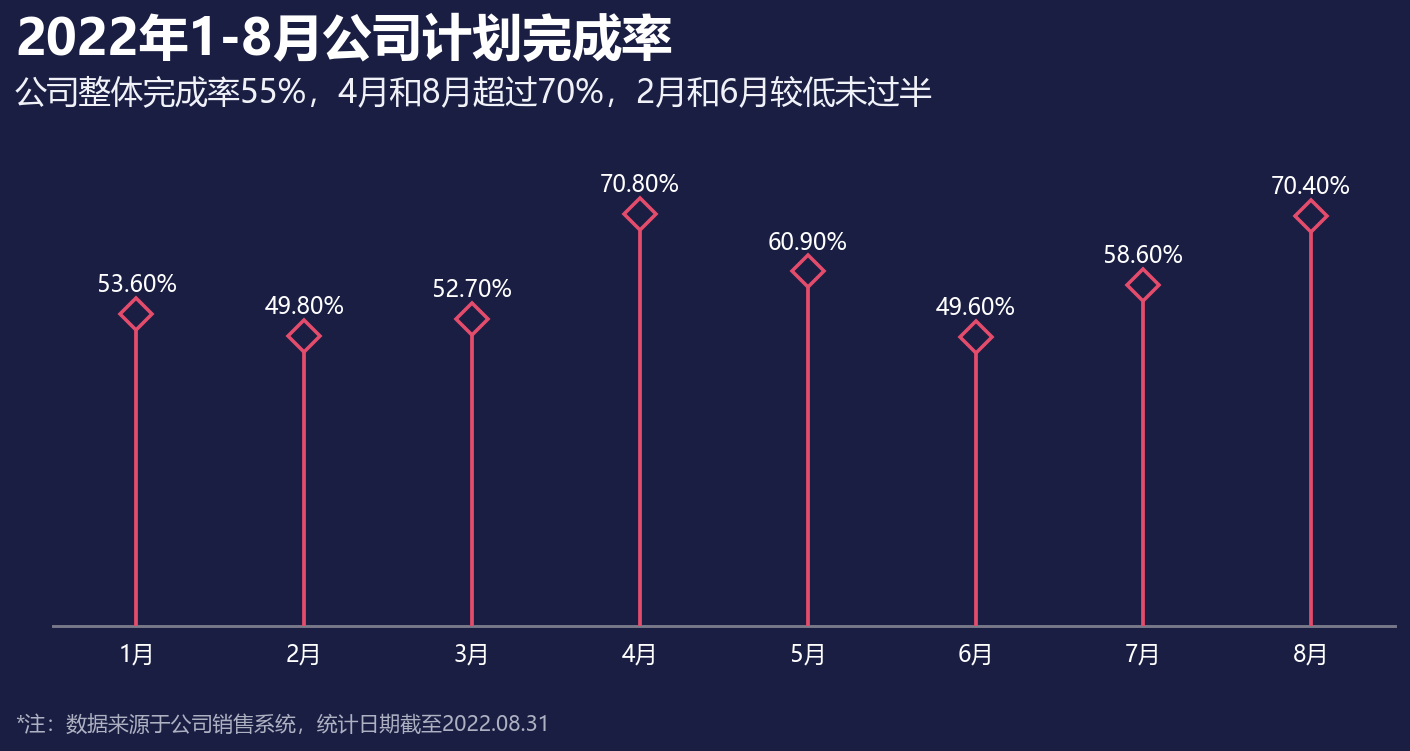

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

months = ["1月", "2月", "3月", "4月", "5月", "6月", "7月", "8月"]
vals   = [53.60, 49.80, 52.70, 70.80, 60.90, 49.60, 58.60, 70.40]

BG   = "#1A1E43"
STEM = "#E44C6C"
AXIS = "#787888"  
TEXT = "#FFFFFF"
SOFT = "#F0F2F8"
GRAY = "#AEB1C2"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
fig.subplots_adjust(left=0.075, right=0.97, top=0.78, bottom=0.25)

x = np.arange(len(months))

ax.vlines(x, 0, vals, color=STEM, lw=1.8, zorder=3)
ax.plot(x, vals, ls="none", marker="D", ms=11, mew=1.7,
        mfc=BG, mec=STEM, zorder=4)  

for i, v in enumerate(vals):
    ax.text(i, v + 2.8, f"{v:.2f}%", ha="center", va="bottom",
            color=TEXT, fontsize=11, zorder=5)

ax.set_xlim(-0.5, 7.5)
ax.set_ylim(0, 82)
ax.set_xticks(x)
ax.set_xticklabels(months, color=TEXT, fontsize=11)
ax.set_yticks([])
ax.tick_params(axis="x", length=0, pad=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color(AXIS)
ax.spines["bottom"].set_linewidth(1.4)

ax.text(-0.028, 1.17, "2022年1-8月公司计划完成率", transform=ax.transAxes,
        color=TEXT, fontsize=24, fontweight="bold", va="bottom")
ax.text(-0.028, 1.08, "公司整体完成率55%，4月和8月超过70%，2月和6月较低未过半",
        transform=ax.transAxes, color=SOFT, fontsize=15.5, va="bottom")
ax.text(-0.028, -0.185, "*注：数据来源于公司销售系统，统计日期截至2022.08.31",
        transform=ax.transAxes, color=GRAY, fontsize=10, va="top")

plt.savefig("12 菱形走势图.png", facecolor=BG)

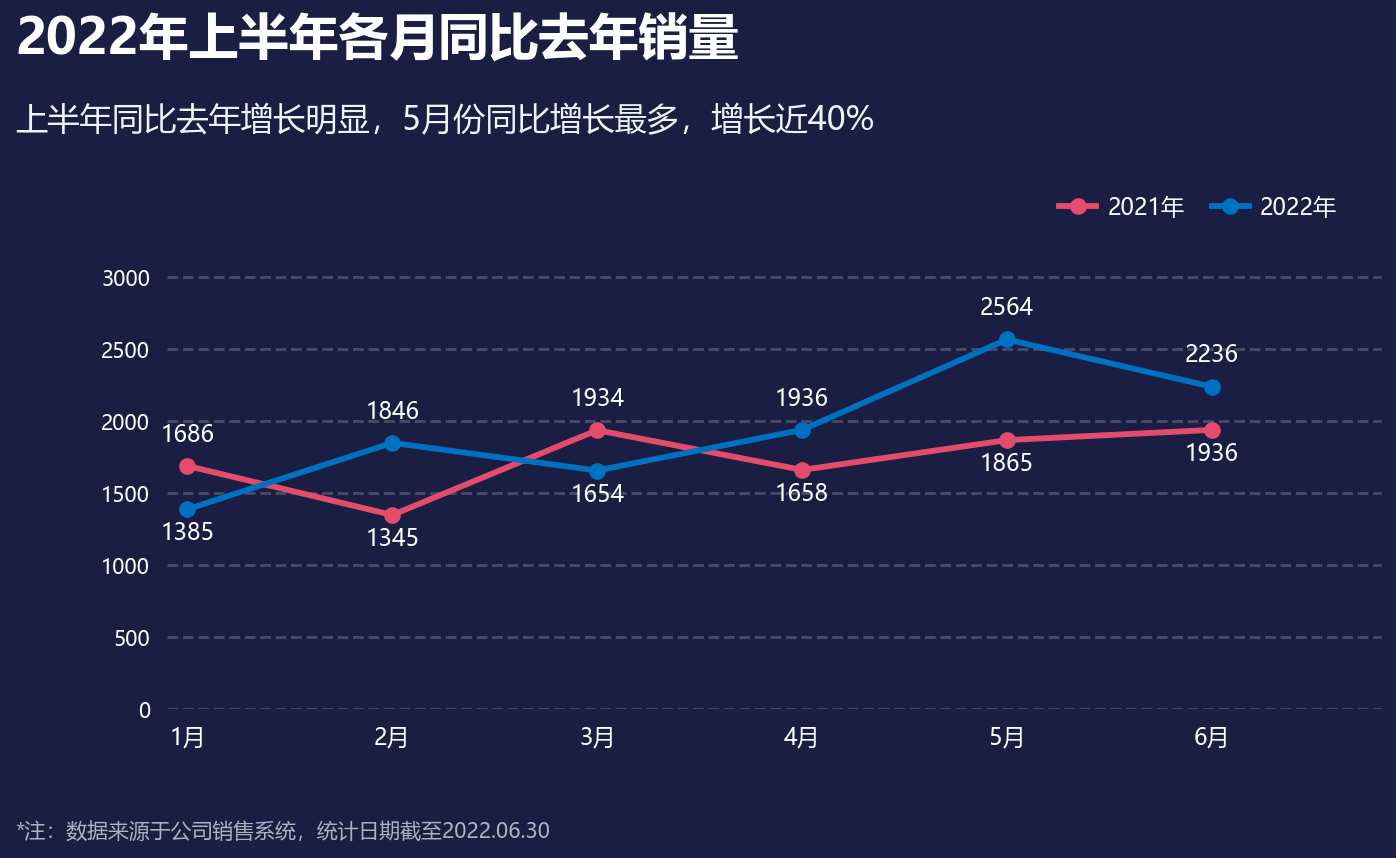

In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

months = ["1月", "2月", "3月", "4月", "5月", "6月"]
v2021  = [1686, 1345, 1934, 1658, 1865, 1936]
v2022  = [1385, 1846, 1654, 1936, 2564, 2236]

BG   = "#1A1E43"
PINK = "#E44C6C"  
BLUE = "#0070C0" 
GRID = "#484868" 
TEXT = "#FFFFFF"
SOFT = "#F0F2F8"
GRAY = "#AEB1C2"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
fig.subplots_adjust(left=0.155, right=0.965, top=0.68, bottom=0.16)

x = np.arange(6)
ax.plot(x, v2021, color=PINK, lw=2.8, marker="o", ms=7, zorder=3)
ax.plot(x, v2022, color=BLUE, lw=2.8, marker="o", ms=7, zorder=3)

for i in range(6):
    hi, lo = (v2021[i], v2022[i]) if v2021[i] >= v2022[i] else (v2022[i], v2021[i])
    ax.text(i, hi + 130, f"{hi}", ha="center", va="bottom", color=TEXT,
            fontsize=11, zorder=5)
    ax.text(i, lo - 80, f"{lo}", ha="center", va="top", color=TEXT,
            fontsize=11, zorder=5)

ax.set_xlim(-0.10, 5.83)    
ax.set_ylim(0, 3250)
ax.set_xticks(x)
ax.set_xticklabels(months, color=TEXT, fontsize=11)
ax.set_yticks(np.arange(0, 3001, 500))
ax.tick_params(length=0, pad=8, labelcolor=TEXT)
ax.set_axisbelow(True)
ax.grid(axis="y", ls="--", lw=1.4, color=GRID)
for sp in ax.spines.values():
    sp.set_visible(False)

ax.legend(["2021年", "2022年"], loc="lower right", bbox_to_anchor=(0.98, 1.0),
          ncol=2, frameon=False, labelcolor=TEXT, fontsize=11,
          handlelength=1.6, handletextpad=0.5, columnspacing=1.2)

ax.text(-0.125, 1.37, "2022年上半年各月同比去年销量", transform=ax.transAxes,
        color=TEXT, fontsize=24, fontweight="bold", va="bottom")
ax.text(-0.125, 1.22, "上半年同比去年增长明显，5月份同比增长最多，增长近40%",
        transform=ax.transAxes, color=SOFT, fontsize=15.5, va="bottom")
ax.text(-0.125, -0.24, "*注：数据来源于公司销售系统，统计日期截至2022.06.30",
        transform=ax.transAxes, color=GRAY, fontsize=10, va="top")

plt.savefig("13 对比折线图.png", facecolor=BG)

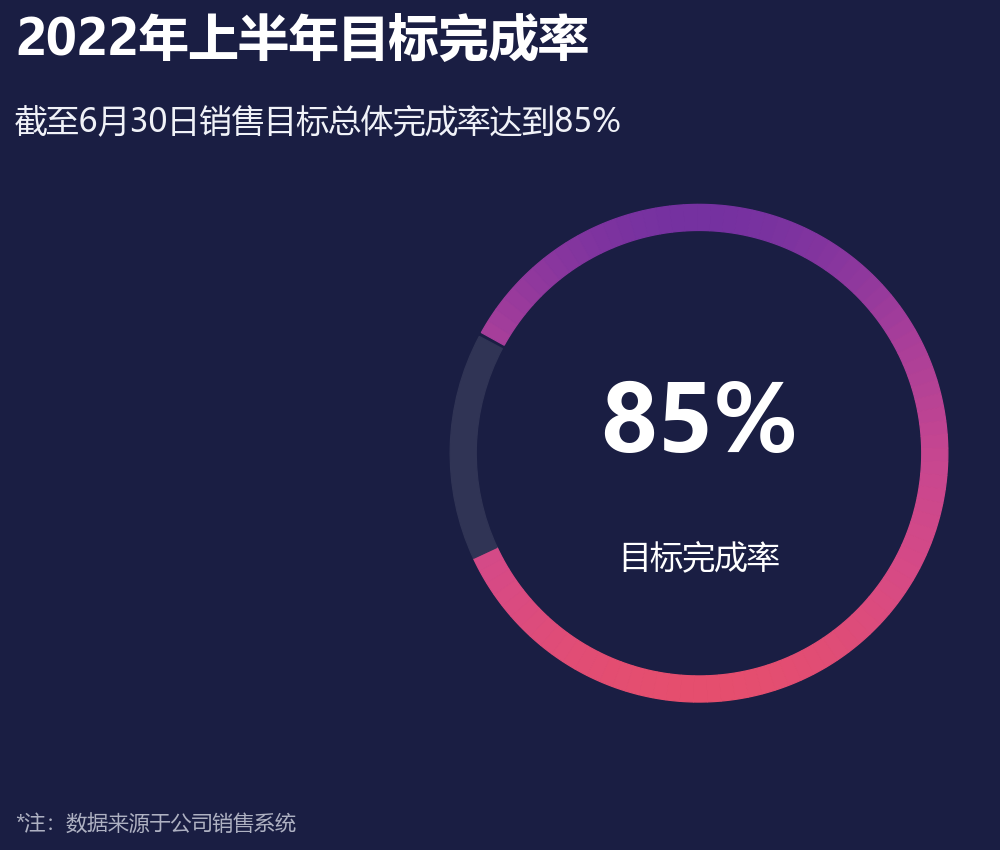

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Wedge

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

BG   = "#1A1E43"
DARK = "#303455"     
TEXT = "#FFFFFF"
SOFT = "#F0F2F8"
GRAY = "#AEB1C2"
STOPS = [(0.00, "#7531A0"), (0.25, "#A73E9A"), (0.50, "#C64690"),
         (0.75, "#D64A86"), (1.00, "#E54E6E")] 

def grad(t):
    t = min(max(t, 0.0), 1.0)
    for (t0, c0), (t1, c1) in zip(STOPS, STOPS[1:]):
        if t <= t1:
            f = (t - t0) / (t1 - t0)
            a, b = np.array(to_rgb(c0)), np.array(to_rgb(c1))
            return tuple(a + (b - a) * f)
    return to_rgb(STOPS[-1][1])

fig = plt.figure(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)

FW, FH = fig.get_size_inches()    
BOX_IN = 0.553 * FH * 1.15         
FX, FY = 0.5, 0.447            
axd = fig.add_axes([FX - BOX_IN / 2 / FW, FY - BOX_IN / 2 / FH,
                    BOX_IN / FW, BOX_IN / FH])
axd.set_xlim(-1.15, 1.15)
axd.set_ylim(-1.15, 1.15)
axd.set_aspect("equal")
axd.axis("off")

R_OUT, R_IN = 1.0, 0.895       
TH_START, TH_SWEEP = 299, 306     
N = 96
for k in range(N):
    m1 = TH_START + TH_SWEEP * k / N
    m2 = TH_START + TH_SWEEP * (k + 1) / N
    th_mid = math.radians((m1 + m2) / 2 % 360)
    c = grad((1 - math.cos(th_mid)) / 2) 
    p1, p2 = 90 - m1, 90 - m2        
    axd.add_patch(Wedge((0, 0), R_OUT, p2, p1, width=R_OUT - R_IN,
                        facecolor=c, edgecolor=c, lw=0.6, zorder=3))

axd.add_patch(Wedge((0, 0), R_OUT, 90 - 298, 90 - 245, width=R_OUT - R_IN,
                    facecolor=DARK, edgecolor=DARK, lw=0.6, zorder=3))

axd.text(0, 0.11, "85%", ha="center", va="center", color=TEXT,
         fontsize=44, fontweight="bold")
axd.text(0, -0.42, "目标完成率", ha="center", va="center", color=TEXT, fontsize=15.5)

fig.text(0.044, 0.905, "2022年上半年目标完成率", color=TEXT, fontsize=24,
         fontweight="bold", va="center")
fig.text(0.044, 0.815, "截至6月30日销售目标总体完成率达到85%", color=SOFT,
         fontsize=15.5, va="center")
fig.text(0.044, 0.035, "*注：数据来源于公司销售系统", color=GRAY, fontsize=10,
         va="center")

plt.savefig("14 单值圆环图.png", facecolor=BG)

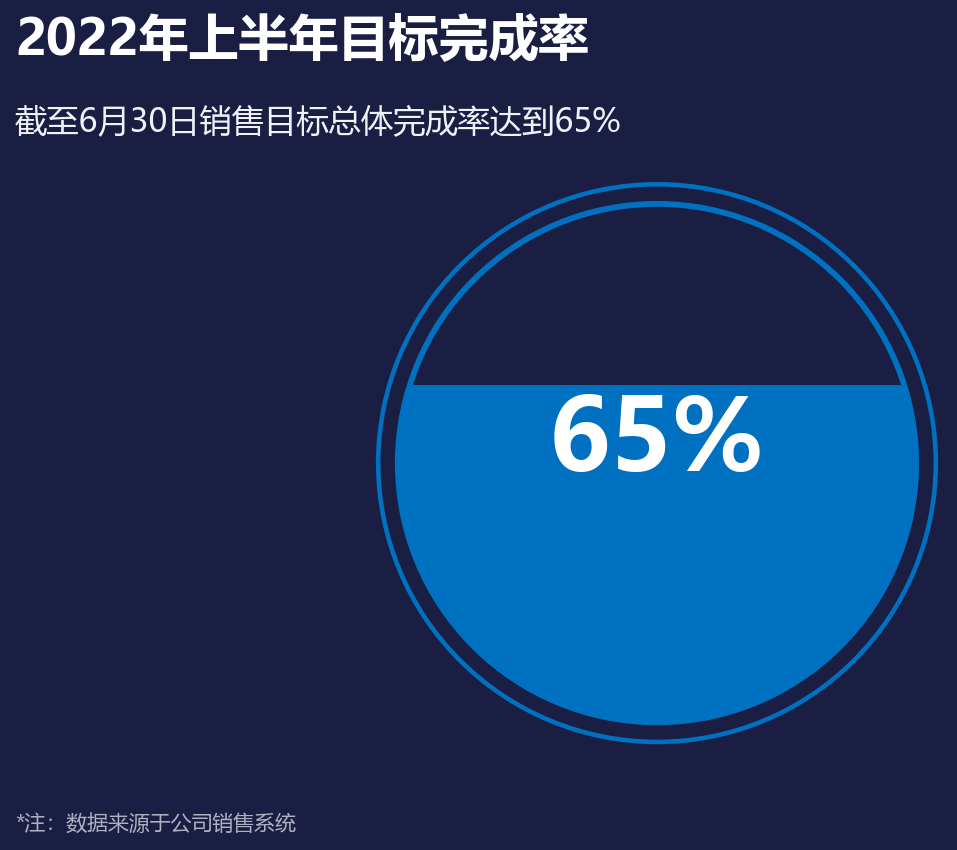

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

BG   = "#1A1E43"
BLUE = "#0070C0"    
TEXT = "#FFFFFF"
SOFT = "#F0F2F8"
GRAY = "#AEB1C2"

PCT = 0.65          

fig = plt.figure(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor(BG)

MAIN_D_IN = 0.576 * 6.2         
BOX_IN = MAIN_D_IN * 1.10       
FX, FY = 0.472, 0.436 
axd = fig.add_axes([FX - BOX_IN / 2 / 10, FY - BOX_IN / 2 / 6.2,
                    BOX_IN / 10, BOX_IN / 6.2])
axd.set_xlim(-1.10, 1.10)
axd.set_ylim(-1.10, 1.10)
axd.set_aspect("equal")
axd.axis("off")

main = Circle((0, 0), 1.0, facecolor="none", edgecolor=BLUE, lw=2.8, zorder=3)
axd.add_patch(main)
water = Rectangle((-1.2, -1.0), 2.4, 2 * PCT, facecolor=BLUE,
                  edgecolor="none", zorder=2)
water.set_clip_path(main)
axd.add_patch(water)

axd.add_patch(Circle((0, 0), 1.0757, facecolor="none", edgecolor=BLUE,
                     lw=2.2, zorder=3))

axd.text(0, 0.076, f"{int(PCT * 100)}%", ha="center", va="center",
         color=TEXT, fontsize=48, fontweight="bold", zorder=4)

fig.text(0.044, 0.905, "2022年上半年目标完成率", color=TEXT, fontsize=24, fontweight="bold", va="center")
fig.text(0.044, 0.815, "截至6月30日销售目标总体完成率达到65%", color=SOFT, fontsize=15.5, va="center")
fig.text(0.044, 0.035, "*注：数据来源于公司销售系统", color=GRAY, fontsize=10, va="center")

plt.savefig("15 水球图.png", facecolor=BG)